# Assignment Module 2: Aircraft Classification

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/). The assignment is divided into two parts: first, you will be asked to implement your own neural network for image classification from scratch; then, you will fine-tune a pretrained network provided by PyTorch.

![](https:///raw.githubusercontent.com/CVLAB-Unibo/ipcv-assignment-2/master/fgvc_aircraft_variants.svg)

## Dataset

Download and acces the dataset through its official [PyTorch `FGVCAircraft` class](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html) (by setting its constructor argument `annotation_level` to `'variant'`).

## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

## Solution notes

The code below follows the same style used in the lab notebooks: a `cfg` dictionary for hyperparameters, a `fix_random` helper, explicit PyTorch modules, `DataLoader` objects, and a compact `Trainer` class. The assignment text above is kept unchanged.


## Import dependencies


In [1]:
import copy
import json
import random
import time
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional
from google.colab import drive

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

from tqdm.notebook import tqdm

from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
from torch.utils.data import DataLoader, Subset,ConcatDataset
from torchvision import datasets, transforms as T
from torchvision.models import resnet18, ResNet18_Weights


## Runtime settings


In [2]:
def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


fix_random(seed=42)


device = "cpu"
if torch.cuda.is_available():
    print("All good, a GPU is available")
    device = torch.device("cuda:0")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    print("Using Apple Silicon GPU through MPS")
    device = torch.device("mps")
else:
    print("Using CPU")
drive.mount('/content/drive',force_remount=True)
path_default = Path("/content/drive/MyDrive/IPCV_E2/")
# path_default = Path(".")



path_data = path_default / Path("data")
path_outputs = path_default / Path("outputs")
path_ckpts = path_default / path_outputs / "ckpts"
path_histories = path_outputs / "histories"
path_plots = path_outputs / "plots"

# check if paths not exist make it
if not path_default.exists():
    path_default.mkdir()
if not path_data.exists():
    path_data.mkdir()
if not path_outputs.exists():
    path_outputs.mkdir()
if not path_ckpts.exists():
    path_ckpts.mkdir()
if not path_histories.exists():
    path_histories.mkdir()
if not path_plots.exists():
    path_plots.mkdir()
DOWNLOAD_DATA = True
RUN_TRAINING = True
FAST_DEV_RUN = False
SHOW_DATASET_PREVIEW = True
PIN_MEMORY = torch.cuda.is_available()
cfg = {
    "resize_size": 256,
    "crop_size": 224,

    "batch_size": 64,
    "num_epochs": 35,

    "lr": 3e-4,
    "head_lr": None,
    "wd": 1e-4,
    "label_smoothing": 0.1,

    "dropout": 0.35,
    "channels": [32, 64, 128, 256, 384],
    "use_batch_norm": True,
    "augmentation": "light",
    "random_erasing": True,
    "freeze_backbone": False,

    "run_name": "custom_cnn_best"
}

pd.DataFrame.from_dict(cfg, orient="index", columns=["value"])


All good, a GPU is available
Mounted at /content/drive


,value
resize_size,256
crop_size,224
batch_size,64
num_epochs,35
lr,0.0003
head_lr,None
wd,0.0001
label_smoothing,0.1
dropout,0.35
channels,"[32, 64, 128, 256, 384]"


## Dataset and transforms


In [3]:
mean_image_net = [0.485, 0.456, 0.406]
std_image_net = [0.229, 0.224, 0.225]


def get_train_transform(cfg: Dict[str, Any]) -> T.Compose:
    if cfg["augmentation"] == "none":
        transform_list = [
            T.Resize((cfg["crop_size"], cfg["crop_size"])),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    elif cfg["augmentation"] == "light":
        transform_list = [
            T.Resize(cfg["resize_size"]),
            T.RandomCrop(cfg["crop_size"]),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    elif cfg["augmentation"] == "strong":
        transform_list = [
            T.RandomResizedCrop(
                cfg["crop_size"],
                scale=(0.88, 1.0),
                ratio=(0.95, 1.05),
            ),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(8),
            T.ColorJitter(
                brightness=0.08,
                contrast=0.08,
                saturation=0.08,
                hue=0.01,
            ),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    elif cfg["augmentation"] == "resnet_strong":
        transform_list = [
            T.RandomResizedCrop(cfg["crop_size"], scale=(0.60, 1.00), ratio=(0.80, 1.20)),
            T.RandomHorizontalFlip(),
            T.RandAugment(num_ops=2, magnitude=9),
            T.ToTensor(),
            T.Normalize(mean_image_net, std_image_net)
        ]
    else:
        raise ValueError(f"Unknown augmentation policy: {cfg['augmentation']}")

    if cfg.get("random_erasing", False):
        transform_list.append(T.RandomErasing(p=0.10, scale=(0.02, 0.05)))

    return T.Compose(transform_list)


def get_eval_transform(cfg: Dict[str, Any]) -> T.Compose:
    return T.Compose([
        T.Resize(cfg["resize_size"]),
        T.CenterCrop(cfg["crop_size"]),
        T.ToTensor(),
        T.Normalize(mean_image_net, std_image_net)
    ])

def mixup(x, y, num_classes, alpha=0.2, prob=0.5):
    y_onehot = F.one_hot(y, num_classes).float()
    if np.random.rand() > prob or alpha <= 0:
        return x, y_onehot  # skip mixing this batch
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x = lam * x + (1 - lam) * x[idx]
    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[idx]
    return x, y_mixed

def take_subset(dataset, max_items: int):
    indices = torch.randperm(len(dataset))[:max_items]
    return Subset(dataset, indices.tolist())


def get_datasets(cfg: Dict[str, Any]):
    data_train = datasets.FGVCAircraft(
        root=path_data,
        split="train",
        annotation_level="variant",
        transform=get_train_transform(cfg),
        download=DOWNLOAD_DATA,

    )
    data_val = datasets.FGVCAircraft(
        root=path_data,
        split="val",
        annotation_level="variant",
        transform=get_eval_transform(cfg),
        download=DOWNLOAD_DATA
    )
    data_test = datasets.FGVCAircraft(
        root=path_data,
        split="test",
        annotation_level="variant",
        transform=get_eval_transform(cfg),
        download=DOWNLOAD_DATA
    )

    classes = data_train.classes

    if FAST_DEV_RUN:
        data_train = take_subset(data_train, 512)
        data_val = take_subset(data_val, 256)
        data_test = take_subset(data_test, 256)

    return data_train, data_val, data_test, classes


def get_loaders(data_train, data_val, data_test, cfg: Dict[str, Any]):
    loader_train = DataLoader(
        data_train,
        batch_size=cfg["batch_size"],
        shuffle=True,
        pin_memory=PIN_MEMORY
    )
    loader_val = DataLoader(
        data_val,
        batch_size=cfg["batch_size"],
        shuffle=False,
        pin_memory=PIN_MEMORY
    )
    loader_test = DataLoader(
        data_test,
        batch_size=cfg["batch_size"],
        shuffle=False,
        pin_memory=PIN_MEMORY
    )

    return loader_train, loader_val, loader_test


# Train samples = 3334
# Val samples = 3333
# Test samples = 3333
# Classes = 100


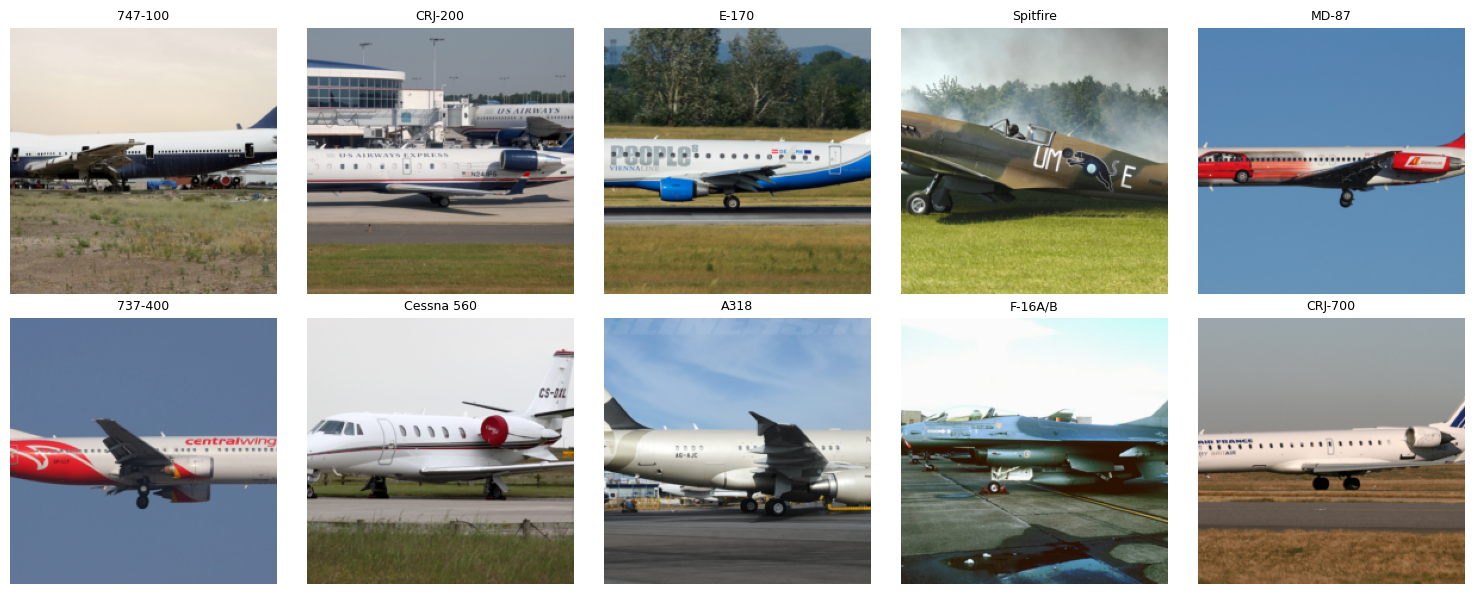

In [7]:
class NormalizeInverse(T.Normalize):
    def __init__(self, mean: List[float], std: List[float]) -> None:
        """Reconstructs the images in the input domain by inverting
        the normalization transformation.

        Args:
            mean: the mean used to normalize the images.
            std: the standard deviation used to normalize the images.
        """
        mean = torch.as_tensor(mean)
        std = torch.as_tensor(std)
        std_inv = 1 / (std + 1e-7)
        mean_inv = -mean * std_inv
        super().__init__(mean=mean_inv, std=std_inv)

    def __call__(self, tensor):
        return super().__call__(tensor.clone())


def show_grid(dataset, classes: List[str], process: Callable = None) -> None:
    """Shows a grid with random images taken from the dataset."""
    fig = plt.figure(figsize=(15, 6))
    indices_random = np.random.randint(10, size=10, high=len(dataset))

    for count, idx in enumerate(indices_random):
        fig.add_subplot(2, 5, count + 1)
        image, label = dataset[idx]
        title = classes[label]
        plt.title(title, fontsize=9)
        image_processed = process(image) if process is not None else image
        plt.imshow(T.ToPILImage()(image_processed))
        plt.axis("off")

    plt.tight_layout()
    plt.show()


denormalize = NormalizeInverse(mean_image_net, std_image_net)

if SHOW_DATASET_PREVIEW:

    data_train_preview, data_val_preview, data_test_preview, classes = get_datasets(cfg)
    print(f"# Train samples = {len(data_train_preview)}")
    print(f"# Val samples = {len(data_val_preview)}")
    print(f"# Test samples = {len(data_test_preview)}")
    print(f"# Classes = {len(classes)}")
    show_grid(data_val_preview, classes, process=denormalize)


## Training utilities


In [5]:
def ncorrect(scores, y):
    y_hat = torch.argmax(scores, -1)
    return (y_hat == y).sum()


def accuracy(scores, y):
    correct = ncorrect(scores, y)
    return correct.true_divide(y.shape[0])


def count_parameters(model: nn.Module, trainable_only: bool = False) -> int:
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def get_optimizer(model: nn.Module, cfg: Dict[str, Any]):
    params = []

    if cfg.get("head_lr") is not None:
        backbone_params = []
        head_params = []
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if name.startswith("fc") or name.startswith("classifier"):
                head_params.append(p)
            else:
                backbone_params.append(p)

        if len(backbone_params) > 0:
            params.append({"params": backbone_params, "lr": cfg["lr"]})
        if len(head_params) > 0:
            params.append({"params": head_params, "lr": cfg["head_lr"]})
    else:
        params = [p for p in model.parameters() if p.requires_grad]

    return AdamW(params, lr=cfg["lr"], weight_decay=cfg["wd"])


class Trainer:
    def __init__(
            self,
            model: nn.Module,
            train_loader: DataLoader,
            val_loader: DataLoader,
            device: torch.device,
            cfg: Dict[str, Any]
        ) -> None:
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.cfg = cfg
        self.num_epochs = cfg["num_epochs"]

        self.model = model.to(device)
        self.optimizer = get_optimizer(self.model, cfg)
        max_lr = [group["lr"] for group in self.optimizer.param_groups]
        print(f"Max learning rates for OneCycleLR: {max_lr}")
        self.scheduler = OneCycleLR(
            self.optimizer,
            max_lr=max_lr,
            total_steps=self.num_epochs * len(train_loader)
        )


        self.step = 0
        self.best_acc = 0.0
        self.best_epoch = -1
        self.best_params = copy.deepcopy(self.model.state_dict())


        # Early stopping
        self.best_val_acc = float(-1)
        self.patience = self.cfg.get("early_stop_patience", 20)          # stop after 20 epochs without val loss improvement
        self.min_delta = 1e-4       # minimum decrease in val loss to count as improvement
        self.epochs_without_improvement = 0


        self.history = []
        self.ckpt_path = path_ckpts / f"{cfg['run_name']}.pt"

    def eval(self, loader, return_cm=False):
        self.model.eval()

        total_loss = 0
        total_samples = 0
        total_acc = 0

        if return_cm:
            all_preds = []
            all_labels = []

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                scores = self.model(imgs)
                loss = F.cross_entropy(scores, labels, reduction="sum")

                total_loss += loss.item()
                total_samples += imgs.size(0)
                total_acc += ncorrect(scores, labels).item()

                if return_cm:
                    preds = scores.argmax(dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

        total_loss /= total_samples
        total_acc /= total_samples

        if return_cm:
            cm = confusion_matrix(all_labels, all_preds)
            return total_loss, total_acc, cm

        return total_loss, total_acc

    def train(self) -> None:
        for e in tqdm(range(self.num_epochs), desc="Epoch"):
            print(f"\nTraining epoch {e + 1}/{self.num_epochs}")

            self.model.train()

            train_loss = 0.0
            train_acc = 0
            train_samples = 0

            pbar = tqdm(self.train_loader, desc=f"Epoch {e + 1}/{self.num_epochs}")

            for imgs, labels in pbar:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                imgs_mixed, labels_mixed = mixup(
                    imgs,
                    labels,
                    self.cfg.get("num_classes", 100),
                    alpha=self.cfg.get("mixup_alpha", 0.2),
                    prob=self.cfg.get("mixup_prob", 0.5),
                )

                scores = self.model(imgs_mixed)

                log_probs = F.log_softmax(scores, dim=1)

                if self.cfg.get("label_smoothing", 0.0) > 0:
                    num_classes = scores.shape[1]
                    smoothing = self.cfg["label_smoothing"]
                    labels_mixed = (
                        labels_mixed * (1 - smoothing)
                        + smoothing / num_classes
                    )

                loss = -(labels_mixed * log_probs).sum(dim=1).mean()

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), max_norm=5.0
                )
                self.optimizer.step()
                self.scheduler.step()

                train_loss += loss.item() * imgs.size(0)
                train_acc += ncorrect(scores, labels).item()
                train_samples += imgs.size(0)

                pbar.set_postfix(loss=f"{loss.item():.4f}")

                self.step += 1

            train_loss /= train_samples
            train_acc /= train_samples

            val_loss, val_acc = self.eval(self.val_loader)

            current_lr = self.optimizer.param_groups[0]["lr"]

            self.history.append({
                "epoch": e + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "lr": current_lr,
            })

            print(
                f"Epoch {e + 1:03d}/{self.num_epochs} | "
                f"LR: {current_lr:.2e} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

            # ----------------------------------------------------
            # Save best model according to validation accuracy
            # ----------------------------------------------------
            if val_acc > self.best_acc:
                self.best_acc = val_acc
                self.best_epoch = e + 1
                self.best_params = copy.deepcopy(self.model.state_dict())
                torch.save(self.best_params, self.ckpt_path)

                print(f"✓ Saved new best model (val_acc={val_acc:.4f})")

            # ----------------------------------------------------
            # Early stopping according to validation accuracy
            # ----------------------------------------------------
            if val_acc > self.best_val_acc + self.min_delta:
                self.best_val_acc = val_acc
                self.epochs_without_improvement = 0
            else:
                self.epochs_without_improvement += 1

                print(
                    f"Validation accuracy did not improve "
                    f"({self.epochs_without_improvement}/{self.patience})"
                )

                if self.epochs_without_improvement >= self.patience:
                    print("\nEarly stopping triggered.")
                    print(
                        f"Best validation accuracy: {self.best_acc:.4f} "
                        f"(epoch {self.best_epoch})"
                    )
                    break



        if self.best_params is not None:
            self.model.load_state_dict(self.best_params)

        print(
            f"\nTraining complete. "
            f"Best validation accuracy: {self.best_acc:.4f} "
            f"at epoch {self.best_epoch}."
        )





In [6]:
def plot_confusion_matrix(cm, class_names=None, normalize=False, save_path= None):
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm = cm.clip(min=0)

    fig, ax = plt.subplots(figsize=(30, 30))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,

    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        colorbar=True,
        include_values=False,
        values_format=".2f" if normalize else "d"
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
def run_experiment(cfg_exp: Dict[str, Any], get_model_fn: Callable):
    fix_random(seed=42)

    data_train, data_val, data_test, classes = get_datasets(cfg_exp)
    loader_train, loader_val, loader_test = get_loaders(data_train, data_val, data_test, cfg_exp)


    model = get_model_fn(len(classes), cfg_exp)
    print(f"Run name = {cfg_exp['run_name']}")
    print(f"Total parameters = {count_parameters(model):,}")
    print(f"Trainable parameters = {count_parameters(model, trainable_only=True):,}")

    trainer = Trainer(
        model,
        loader_train,
        loader_val,
        device,
        cfg_exp
    )

    start_time = time.time()
    trainer.train()
    elapsed = (time.time() - start_time) / 60

    test_loss, test_acc,cm = trainer.eval(loader_test,True)
    plot_confusion_matrix(
    cm,
    class_names=data_train.classes,
    normalize=True,
    save_path = path_plots / (cfg_exp["run_name"] + "_conf.png")
)
    history = pd.DataFrame(trainer.history)
    history.to_csv(path_histories / f"{cfg_exp['run_name']}.csv", index=False)

    result = {
        "run_name": cfg_exp["run_name"],
        "best_val_acc": trainer.best_acc,
        "best_epoch": trainer.best_epoch,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "elapsed_min": elapsed,
        "total_parameters": count_parameters(trainer.model),
        "trainable_parameters": count_parameters(trainer.model, trainable_only=True),
        "cfg": copy.deepcopy(cfg_exp),
        "history": history
    }

    result_to_save = copy.deepcopy(result)
    result_to_save.pop("history")
    with open(path_outputs / f"{cfg_exp['run_name']}_summary.json", "w") as f:
        json.dump(result_to_save, f, indent=2)

    print(f"Best val acc = {trainer.best_acc:.3f}")
    print(f"Test acc = {test_acc:.3f}")

    return result


def results_to_table(results: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for run_name, result in results.items():
        rows.append({
            "run_name": run_name,
            "best_val_acc": result["best_val_acc"],
            "test_acc": result["test_acc"],
            "test_loss": result["test_loss"],
            "best_epoch": result["best_epoch"],
            "augmentation": result["cfg"]["augmentation"],
            "lr": result["cfg"]["lr"],
            "head_lr": result["cfg"].get("head_lr"),
            "wd": result["cfg"]["wd"],
            "dropout": result["cfg"].get("dropout"),
            "label_smoothing": result["cfg"].get("label_smoothing"),
            "freeze_backbone": result["cfg"].get("freeze_backbone"),
            "trainable_parameters": result["trainable_parameters"]
        })

    table = pd.DataFrame(rows)
    if len(table) > 0:
        table = table.sort_values("test_acc", ascending=False).reset_index(drop=True)
    return table


def plot_results(results: Dict[str, Dict[str, Any]], save_path: Path = None) -> None:
    _, ax = plt.subplots(1, 2, figsize=(14, 4))

    for run_name, result in results.items():
        history = result["history"]
        ax[0].plot(history["epoch"], history["train_acc"], label=f"{run_name} train")
        ax[1].plot(history["epoch"], history["val_acc"], label=f"{run_name} val")

    ax[0].set_title("Training accuracy")
    ax[1].set_title("Validation accuracy")
    for axis in ax:
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Accuracy")
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()








## Part 1 solution: custom CNN

The network below is built only from PyTorch layers. It does not instantiate any pretrained or off-the-shelf torchvision model.


In [ ]:
class BasicBlock(nn.Module):
    """
    A standard ResNet block with a skip connection.
    """
    def __init__(self, in_channels, out_channels, stride=1, use_batch_norm=True):
        super().__init__()
        self.use_batch_norm = use_batch_norm

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=not use_batch_norm)
        if use_batch_norm:
            self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=not use_batch_norm)
        if use_batch_norm:
            self.bn2 = nn.BatchNorm2d(out_channels)

        # The shortcut matches dimensions if stride > 1 or channel sizes differ
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            shortcut_modules = [nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=not use_batch_norm)]
            if use_batch_norm:
                shortcut_modules.append(nn.BatchNorm2d(out_channels))
            self.shortcut = nn.Sequential(*shortcut_modules)

    def forward(self, x):
        out = self.conv1(x)
        if self.use_batch_norm: out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        if self.use_batch_norm: out = self.bn2(out)

        # Add the skip connection before the final ReLU
        out += self.shortcut(x)
        out = F.relu(out)
        return out
class AircraftCNN(nn.Module):
    """
    Custom ResNet-like CNN built entirely from scratch.
    """
    def __init__(self, num_classes: int, cfg: Dict[str, Any]):
        super().__init__()

        self.use_batch_norm = cfg.get("use_batch_norm", True)
        channels = cfg["channels"]
        self.in_channels = channels[0]

        # Initial Downsampling Block
        modules = [
            nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=not self.use_batch_norm)
        ]
        if self.use_batch_norm:
            modules.append(nn.BatchNorm2d(self.in_channels))
        modules.append(nn.ReLU())
        modules.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

        self.conv1 = nn.Sequential(*modules)

        # Residual Blocks Stages
        blocks = []
        for i, out_channels in enumerate(channels):
            # Downsample on the first block of each stage except the first stage
            stride = 1 if i == 0 else 2
            blocks.append(BasicBlock(self.in_channels, out_channels, stride=stride, use_batch_norm=self.use_batch_norm))
            blocks.append(BasicBlock(out_channels, out_channels, stride=1, use_batch_norm=self.use_batch_norm))
            self.in_channels = out_channels

        self.features = nn.Sequential(*blocks)

        # Classifier Head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(cfg.get("dropout", 0.0)),
            nn.Linear(self.in_channels, num_classes)
        )

        # Initialize weights properly
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.features(x)
        x = self.classifier(x)
        return x
def get_custom_cnn(num_classes: int, cfg: Dict[str, Any]) -> nn.Module:
    return AircraftCNN(num_classes, cfg)

## Part 1 best model hyperparameters


In [ ]:
cfg_part1 = copy.deepcopy(cfg)
cfg_part1["run_name"] = "resnet_mixup_prob_0.5"
cfg_part1["channels"] = [64, 128, 256,512]
cfg_part1["use_batch_norm"] = True
cfg_part1["dropout"] = 0.25
cfg_part1["lr"] = 1e-3
cfg_part1["wd"] = 1e-4
cfg_part1["label_smoothing"] = 0.2
cfg_part1["num_epochs"] = 70
cfg_part1["batch_size"] = 64
cfg_part1["mixup_alpha"] = 0.2
cfg_part1["mixup_prob"] = 0.5
cfg_part1["early_stop_patience"] = 20
cfg_part1["img_size"] = 224
cfg_part1["augmentation"] = "light"

pd.DataFrame.from_dict(cfg_part1, orient="index", columns=["value"])





,value
resize_size,256
crop_size,224
batch_size,64
num_epochs,70
lr,0.001
head_lr,None
wd,0.0001
label_smoothing,0.2
dropout,0.25
channels,"[64, 128, 256, 512]"


In [ ]:
expriment_res= {}
cfg_ex1 =copy.deepcopy(cfg_part1)
cfg_ex1["run_name"]="resnet_mixup_prob_0.5_70epoch"
cfg_ex2 =copy.deepcopy(cfg_part1)
cfg_ex2["run_name"]="resnet_mixup_prob_0.7"
cfg_ex2["mixup_prob"] = 0.7
cfg_ex22 =copy.deepcopy(cfg_part1)
cfg_ex22["run_name"]="resnet_mixup_prob_1"
cfg_ex22["mixup_prob"] = 1
cfg_ex3 =copy.deepcopy(cfg_part1)
cfg_ex3["run_name"]="resnet_mixup_prob_0.3"
cfg_ex3["mixup_prob"] = 0.3
cfg_ex4 =copy.deepcopy(cfg_part1)
cfg_ex4["run_name"]="resnet_reduce_channel"
cfg_ex4["channels"] = [32,64, 128, 256]
cfg_ex5 =copy.deepcopy(cfg_part1)
cfg_ex5["run_name"]="resnet_label_smoothing_0.3"
cfg_ex5["label_smoothing"] = 0.3
cfg_ex55 =copy.deepcopy(cfg_part1)
cfg_ex55["run_name"]="resnet_label_smoothing_0.0"
cfg_ex55["label_smoothing"] = 0.0
cfg_ex555 =copy.deepcopy(cfg_part1)
cfg_ex555["run_name"]="resnet_label_smoothing_0.1"
cfg_ex555["label_smoothing"] = 0.1
cfg_ex6 =copy.deepcopy(cfg_part1)
cfg_ex6["run_name"]="resnet_mixup_alpha_0"
cfg_ex6["mixup_alpha"] = 0
cfg_ex7 =copy.deepcopy(cfg_part1)
cfg_ex7["run_name"]="resnet_mixup_alpha_0.4"
cfg_ex7["mixup_alpha"] = 0.4
cfg_ex8 =copy.deepcopy(cfg_part1)
cfg_ex8["run_name"]="resnet_mixup_alpha_1"
cfg_ex8["mixup_alpha"] = 1
cfg_ex10 =copy.deepcopy(cfg_part1)
cfg_ex10["run_name"]="resnet_batch_norm_false"
cfg_ex10["use_batch_norm"] = False
cfg_ex11 =copy.deepcopy(cfg_part1)
cfg_ex11["run_name"]="resnet_froput_0.5"
cfg_ex11["dropout"] = 0.5
cfg_ex12 =copy.deepcopy(cfg_part1)
cfg_ex12["run_name"]="resnet_droput_0.1"
cfg_ex12["dropout"] = 0.1
cfg_ex122 =copy.deepcopy(cfg_part1)
cfg_ex122["run_name"]="resnet_droput_0.3"
cfg_ex122["dropout"] = 0.3
cfg_ex13 =copy.deepcopy(cfg_part1)
cfg_ex13["run_name"]="resnet_lr_1e-4"
cfg_ex13["lr"] = 1e-4
cfg_ex133 =copy.deepcopy(cfg_part1)
cfg_ex133["run_name"]="resnet_lr_3e-4"
cfg_ex133["lr"] = 3e-4
cfg_ex131 =copy.deepcopy(cfg_part1)
cfg_ex131["run_name"]="resnet_lr_3e-3"
cfg_ex131["lr"] = 3e-3
cfg_ex14 =copy.deepcopy(cfg_part1)
cfg_ex14["run_name"]="resnet_wd_1e-5"
cfg_ex14["wd"] = 1e-5
cfg_ex144 =copy.deepcopy(cfg_part1)
cfg_ex144["run_name"]="resnet_wd_5e-4"
cfg_ex144["wd"] = 5e-4
cfg_ex141 =copy.deepcopy(cfg_part1)
cfg_ex141["run_name"]="resnet_wd_1e-3"
cfg_ex141["wd"] = 1e-3
cfg_ex15 =copy.deepcopy(cfg_part1)
cfg_ex15["run_name"]="resnet_no_aug"
cfg_ex15["augmentation"] = "none"
cfg_ex16 =copy.deepcopy(cfg_part1)
cfg_ex16["run_name"]="resnet_no_random"
cfg_ex16["random_erasing"] = False

part1_exp = [
    cfg_ex1,
    cfg_ex2,
    cfg_ex22,
    cfg_ex3,
    cfg_ex4,
    cfg_ex5,
    cfg_ex55,
    cfg_ex555,
    cfg_ex6,
    cfg_ex7,
    cfg_ex8,
    cfg_ex10,
    cfg_ex11,
    cfg_ex12,
    cfg_ex122,
    cfg_ex13,
    cfg_ex133,
    cfg_ex131,
    cfg_ex14,
    cfg_ex144,
    cfg_ex141,
    cfg_ex15,
    cfg_ex16,

]

if RUN_TRAINING:
    for cfg_exp in part1_exp:
        expriment_res[cfg_exp["run_name"]] = run_experiment(cfg_exp, get_custom_cnn)

    table_exp = results_to_table(expriment_res)
    table_exp.to_csv(path_outputs / "expp_res.csv", index=False)
    display(table_exp)
    plot_results(expriment_res)

# part1_results = {}
# print("Running part 1 experiments...")

# if RUN_TRAINING:
#     part1_results[cfg_part1["run_name"]] = run_experiment(cfg_part1, get_custom_cnn)
#     display(results_to_table(part1_results))
#     plot_results(part1_results, save_path=path_plots / (cfg_part1["run_name"] + ".png"))

# else:
#     print("RUN_TRAINING is False")


basic cnn

## Part 1 ablation: no augmentation

Only the augmentation policy is changed. This checks whether the best model benefits from input diversity.


In [ ]:
cfg_no_aug = copy.deepcopy(cfg_part1)
cfg_no_aug["run_name"] = "part1_ablation_no_augmentation"
cfg_no_aug["augmentation"] = "none"
cfg_no_aug["random_erasing"] = False

pd.DataFrame.from_dict(cfg_no_aug, orient="index", columns=["value"])


## Part 1 ablation: no batch normalization

Only batch normalization is removed. This checks whether normalization improves optimization.


In [ ]:
cfg_no_bn = copy.deepcopy(cfg_part1)
cfg_no_bn["run_name"] = "part1_ablation_no_batch_norm"
cfg_no_bn["use_batch_norm"] = False

pd.DataFrame.from_dict(cfg_no_bn, orient="index", columns=["value"])


## Part 1 ablation: no dropout

Only dropout is removed. This checks whether the classifier head needs this regularization.


In [ ]:
cfg_no_dropout = copy.deepcopy(cfg_part1)
cfg_no_dropout["run_name"] = "part1_ablation_no_dropout"
cfg_no_dropout["dropout"] = 0.0

pd.DataFrame.from_dict(cfg_no_dropout, orient="index", columns=["value"])


## Part 1 ablation: smaller capacity

The number of channels is reduced. This checks whether the best model needs the extra capacity for fine-grained classification.


In [ ]:
cfg_small = copy.deepcopy(cfg_part1)
cfg_small["run_name"] = "part1_ablation_smaller_capacity"
cfg_small["channels"] = [32, 64, 128, 256]
cfg_small["dropout"] = 0.25

pd.DataFrame.from_dict(cfg_small, orient="index", columns=["value"])


In [ ]:
part1_ablation_cfgs = [
    cfg_no_aug,
    cfg_no_bn,
    cfg_no_dropout,
    cfg_small
]

if RUN_TRAINING:
    for cfg_ablation in part1_ablation_cfgs:
        part1_results[cfg_ablation["run_name"]] = run_experiment(cfg_ablation, get_custom_cnn)

    table_part1 = results_to_table(part1_results)
    table_part1.to_csv(path_outputs / "part1_ablation_results.csv", index=False)
    display(table_part1)
    plot_results(part1_results)
else:
    print("RUN_TRAINING is False")


## Part 2 solution: ResNet-18 transfer learning

This part uses the PyTorch ResNet-18 model with ImageNet-1K V1 weights, as required by the assignment.


In [8]:
def set_requires_grad(layer: torch.nn.Module, train: bool) -> None:
    """Sets the requires_grad attribute to True or False for each parameter within a layer.

    Args:
        layer: the layer to freeze.
        train: if true, train the layer.
    """
    for p in layer.parameters():
        p.requires_grad = train


def get_resnet18_model(num_classes: int, cfg: Dict[str, Any]) -> nn.Module:
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)

    classifier = nn.Sequential(
        nn.Dropout(cfg["dropout"]),
        nn.Linear(model.fc.in_features, num_classes)
    )
    model.fc = classifier

    if cfg["freeze_backbone"]:
        set_requires_grad(model.conv1, False)
        set_requires_grad(model.bn1, False)
        set_requires_grad(model.layer1, False)
        set_requires_grad(model.layer2, False)
        set_requires_grad(model.layer3, False)
        set_requires_grad(model.layer4, False)

    return model


## Part 2A: ResNet-18 with Part 1 hyperparameters

The training hyperparameters are copied from the best custom CNN. The only necessary architecture change is replacing the final classifier of ResNet-18.


In [ ]:
cfg_resnet_same = copy.deepcopy(cfg_part1)
cfg_resnet_same["run_name"] = "part2a_resnet18_same_hyperparameters"
cfg_resnet_same["dropout"] = 0.0
cfg_resnet_same["freeze_backbone"] = False
cfg_resnet_same["head_lr"] = None

pd.DataFrame.from_dict(cfg_resnet_same, orient="index", columns=["value"])


,value
resize_size,256
crop_size,224
batch_size,64
num_epochs,30
lr,0.001
head_lr,None
wd,0.00005
label_smoothing,0.1
dropout,0.0
channels,"[64, 128, 256, 512]"


In [ ]:
part2_results = {}

if RUN_TRAINING:
    part2_results[cfg_resnet_same["run_name"]] = run_experiment(cfg_resnet_same, get_resnet18_model)
    display(results_to_table(part2_results))
else:
    print("RUN_TRAINING is False")


## Part 2B: frozen backbone

The ImageNet feature extractor is frozen and only the new classifier is trained. This is the standard first transfer-learning resnetline shown in the lab.


In [ ]:
cfg_resnet_frozen = copy.deepcopy(cfg_resnet_same)
cfg_resnet_frozen["run_name"] = "part2b_resnet18_frozen_backbone"
cfg_resnet_frozen["augmentation"] = "resnet_strong"
cfg_resnet_frozen["random_erasing"] = True
cfg_resnet_frozen["num_epochs"] = 10
cfg_resnet_frozen["lr"] = 1e-3
cfg_resnet_frozen["head_lr"] = None
cfg_resnet_frozen["dropout"] = 0.20
cfg_resnet_frozen["label_smoothing"] = 0.05
cfg_resnet_frozen["freeze_backbone"] = True

pd.DataFrame.from_dict(cfg_resnet_frozen, orient="index", columns=["value"])


## Part 2B: full fine-tuning

After the frozen-backbone resnetline, all ResNet-18 layers are trained with a lower learning rate for the pretrained backbone and a larger learning rate for the new classifier.


In [ ]:
cfg_resnet_finetune = copy.deepcopy(cfg_resnet_same)
cfg_resnet_finetune["run_name"] = "part2b_resnet18_full_finetune"
cfg_resnet_finetune["augmentation"] = "resnet_strong"
cfg_resnet_finetune["random_erasing"] = True
cfg_resnet_finetune["num_epochs"] = 25
cfg_resnet_finetune["lr"] = 1e-4
cfg_resnet_finetune["head_lr"] = 5e-4
cfg_resnet_finetune["dropout"] = 0.20
cfg_resnet_finetune["label_smoothing"] = 0.10
cfg_resnet_finetune["freeze_backbone"] = False

pd.DataFrame.from_dict(cfg_resnet_finetune, orient="index", columns=["value"])


In [ ]:

expriment_resnet= {}
cfg_base_resnet =copy.deepcopy(cfg_part1)
cfg_base_resnet["num_epochs"] = 40
cfg_base_resnet["freeze_backbone"] = False
cfg_base_resnet["augmentation"] = "resnet_strong"
cfg_base_resnet["mixup_prob"] = 1
cfg_base_resnet["mixup_alpha"] = 1
cfg_base_resnet["dropout"] = 0.5
cfg_base_resnet["head_lr"] = 5e-4

cfg_resnet_ex1 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex1["run_name"]="resnet_base"
cfg_resnet_ex2 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex2["run_name"]="resnet_mixup_prob_0.7"
cfg_resnet_ex2["mixup_prob"] = 0.7

cfg_resnet_ex3 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex3["run_name"]="resnet_mixup_prob_0.3"
cfg_resnet_ex3["mixup_prob"] = 0.3
cfg_resnet_ex4 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex4["run_name"]="resnet_label_smoothing_0.25"
cfg_resnet_ex4["label_smoothing"] = 0.25

cfg_resnet_ex5 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex5["run_name"]="resnet_label_smoothing_0.1"
cfg_resnet_ex5["label_smoothing"] = 0.1

cfg_resnet_ex7 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex7["run_name"]="resnet_mixup_alpha_0.4"
cfg_resnet_ex7["mixup_alpha"] = 0.4


cfg_resnet_ex122 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex122["run_name"]="resnet_droput_0.3"
cfg_resnet_ex122["dropout"] = 0.3
cfg_lr1 = copy.deepcopy(cfg_base_resnet)
cfg_lr1["run_name"] = "resnet18_backbone_1e-5_head_1e-4"
cfg_lr1["lr"] = 1e-5
cfg_lr1["head_lr"] = 1e-4

cfg_lr2 = copy.deepcopy(cfg_base_resnet)
cfg_lr2["run_name"] = "resnet18_backbone_3e-5_head_3e-4"
cfg_lr2["lr"] = 3e-5
cfg_lr2["head_lr"] = 3e-4

cfg_lr3 = copy.deepcopy(cfg_base_resnet)
cfg_lr3["run_name"] = "resnet18_backbone_5e-5_head_5e-4"
cfg_lr3["lr"] = 5e-5
cfg_lr3["head_lr"] = 5e-4

cfg_lr4 = copy.deepcopy(cfg_base_resnet)
cfg_lr4["run_name"] = "resnet18_backbone_1e-4_head_5e-4"
cfg_lr4["lr"] = 1e-4
cfg_lr4["head_lr"] = 5e-4

cfg_lr5 = copy.deepcopy(cfg_base_resnet)
cfg_lr5["run_name"] = "resnet18_backbone_1e-4_head_1e-3"
cfg_lr5["lr"] = 1e-4
cfg_lr5["head_lr"] = 1e-3
cfg_resnet_ex14 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex14["run_name"]="resnet_wd_1e-5"
cfg_resnet_ex14["wd"] = 1e-5
cfg_resnet_ex144 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex144["run_name"]="resnet_wd_5e-4"
cfg_resnet_ex144["wd"] = 5e-4
cfg_resnet_ex141 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex141["run_name"]="resnet_wd_1e-3"
cfg_resnet_ex141["wd"] = 1e-3
cfg_resnet_ex15 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex15["run_name"]="resnet_no_aug"
cfg_resnet_ex15["augmentation"] = "none"
cfg_resnet_ex155 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex155["run_name"]="resnet_aug_light"
cfg_resnet_ex155["augmentation"] = "light"

cfg_resnet_ex16 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex16["run_name"]="resnet_no_random"
cfg_resnet_ex16["random_erasing"] = False
cfg_resnet_ex17 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex17["run_name"]="resnet_freeze"
cfg_resnet_ex17["freeze_backbone"] = True
cfg_resnet_ex18 =copy.deepcopy(cfg_base_resnet)
cfg_resnet_ex18["run_name"]="resnet_no_head"
cfg_resnet_ex18["head_lr"] = None

part2b_cfgs = [
   cfg_resnet_ex1,  
   cfg_resnet_ex16,
   cfg_resnet_ex17,
   cfg_resnet_ex18,
   cfg_resnet_ex15,
   cfg_resnet_ex155,
   cfg_resnet_ex2,
   cfg_resnet_ex3,
   cfg_resnet_ex4,
   cfg_resnet_ex5,
   cfg_resnet_ex7,
   cfg_resnet_ex122,
   cfg_lr1,
   cfg_lr2,
   cfg_lr3,
   cfg_lr4,
   cfg_lr5,
   cfg_resnet_ex14,
   cfg_resnet_ex144,
   cfg_resnet_ex141,
   
   
   
]

if RUN_TRAINING:
    for cfg_resnet in part2b_cfgs:
        expriment_resnet[cfg_resnet["run_name"]] = run_experiment(cfg_resnet, get_resnet18_model)

    table_part2 = results_to_table(expriment_resnet)
    table_part2.to_csv(path_outputs / "part2_resnet18_results.csv", index=False)
    display(table_part2)
    plot_results(expriment_resnet)
else:
    print("RUN_TRAINING is False")


## Final comparison

The final table compares the custom CNN, the ablations, and the ResNet-18 experiments.


In [ ]:
all_results = {}
all_results.update(part1_results)
all_results.update(part2_results)

if len(all_results) > 0:
    table_all = results_to_table(all_results)
    table_all.to_csv(path_outputs / "final_model_comparison.csv", index=False)
    display(table_all)
    plot_results(all_results)
else:
    print("Run the training cells to populate the final comparison table.")
